<a href="https://colab.research.google.com/github/ayesha112244/hotel-booking-cancellation-prediction/blob/main/hotel_booking_cancellation_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Cancallation Prediction

**Load Data**

Load Hotel_Booking/hotel_bookings.csv file provided on Brightspace.

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

# For Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


These libraries are used for data analysis, visualisation, and building the machine learning model.

In [ ]:
# Load the dataset into pandas dataframe
df = pd.read_csv('hotel_bookings.csv')

# Display first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


This step loads the hotel bookings dataset into a DataFrame named df and displays the first few rows to understand the structure of the data.

In [ ]:
# Checking dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# Checking shape of dataset
df.shape

(119390, 32)

In [ ]:
# Checking basic statistics
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
# Checking how many cancelled vs not cancelled bookings
df['is_canceled'].value_counts()

,count
is_canceled,
0,75166
1,44224


This gives us information on the dataset's numbeer of rows and coulmns, the datatype of each column, and the number of cancelled or non-cancelled reservations.For instance, if is_cancelled = 0 appears in the majority of rows then the dataset is unbalanced.

# 1. Data Pre-processing (25%)


---






**Drop irrelevant columns**

It will significantly reduce the time and effort you need to invest. As a general guideline, columns containing IDs, dates, or irrelevant information are typically considered redundant and offer little value for predictive analysis.

In [ ]:
# Drop irrelevant columns
df = df.drop(['reservation_status', 'reservation_status_date'], axis=1)

# Check updated shape
df.shape

(119390, 30)

Due to direct disclosure of the desired results, these two columns were eliminated:


*   **reservation_status -->** Gives the model the answer by revealing the final result ("Cancelled,""No-show").

*   **reservation_status_date -->** keeps track of the reservation completion when the cancellation decision has been made, not earlier.

Eliminating these columns guarantees that the model only lerans from real predictive features and prevents bias or leakage.

## Unique values

Find out unique values in columns. This will help you in identifying in-consistent data.

In [ ]:
# Check unique values for categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()[:10]}")
    print('-'*40)

hotel: ['Resort Hotel' 'City Hotel']
----------------------------------------
arrival_date_month: ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April']
----------------------------------------
meal: ['BB' 'FB' 'HB' 'SC' 'Undefined']
----------------------------------------
country: ['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN']
----------------------------------------
market_segment: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Undefined' 'Aviation']
----------------------------------------
distribution_channel: ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']
----------------------------------------
reserved_room_type: ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'P' 'B']
----------------------------------------
assigned_room_type: ['C' 'A' 'D' 'E' 'G' 'F' 'I' 'B' 'H' 'P']
----------------------------------------
deposit_type: ['No Deposit' 'Refundable' 'Non Refund']
----------------------------------------

In [ ]:
# Clean up string columns
df['meal'] = df['meal'].str.strip()
df['market_segment'] = df['market_segment'].str.strip()
df['distribution_channel'] = df['distribution_channel'].str.strip()

In [ ]:
# Replace 'Undefined' with 'Unknown' in relevant columns
df['meal'] = df['meal'].replace('Undefined', 'Unknown')
df['market_segment'] = df['market_segment'].replace('Undefined', 'Unknown')
df['distribution_channel'] = df['distribution_channel'].replace('Undefined', 'Unknown')


All categorical columns were examined for unique values to discover inconsistencies or unexpected entries. There were no extra spaces discovered, although the **meal, market_segment, and distribution_channel** columns contained a few "Undefined" values. These values were changed with "Unknown" to make the dataset more consistent and easy to evaluate. Instead of recognising "Undefined" as a valid value, this guarantees that the model properly interprets missing categories.

## 1.1 Missing Values (10%)

Identify and handle missing values.

In [ ]:
# Identifying missing values
df.isnull().sum().sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4
lead_time,0
arrival_date_year,0
arrival_date_week_number,0
arrival_date_month,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0


In [ ]:
# Drop irrelevant columns
df = df.drop(['company', 'agent'], axis=1)

# Check updated shape
df.shape

(119390, 28)

Due to the higher percentage of missing values "company" and "agent" columns are dropped:


*   **company -->** More than 94% of the values are missing in this column, so it provides minimal helpful information.

*   **agent -->** Booking agent numeric IDs that are not useful for prediction and also this column have higher % of missing values.

Removing them ensures data quality and prevents introducing bias through artificial values.

In [ ]:
# Fill missing children values with 0
df['children'].fillna(0, inplace=True)

# Fill missing country values with 'Unknown'
df['country'].fillna('Unknown', inplace=True)

# Verify
df.isnull().sum().sort_values(ascending=False).head()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0


Only two columns had minor missing data.
*   **"children":** We substitued 0 for the four missing values in the children column since it is logical to assume that missing indicates no children.
*  **"country"**:  We fill in the 488 missing entries (Less than 1%) in the country column with "Unknown" so that we may keep the records for analysis rather than dropping them.

Dropping would result in an unnecessary of the dataset, whereas this method maintains consistency.

## 1.2 Removing Inconsistent values and Outliers (10%)

Detecting inconsistencies can be achieved through a variety of methods. Some can be identified by examining unique values within each column, while others may require a solid understanding of the problem domain. Since you might not be an expert in the hotel or hospitality industry, here are some helpful hints:

Hints:

1. Check for incomplete bookings, such as reservations with zero adults, babies, or children.
2. Examine rows with zeros in both 'stays_in_weekend_nights' and 'stays_in_week_nights.'



In [ ]:
# Find invalid bookings where there are no guests (adults, children, babies all 0)
invalid_guests = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print("Invalid guest rows:", len(invalid_guests))

# Remove those rows
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]
print("Dataset shape after removing invalid guests:", df.shape)

Invalid guest rows: 180
Dataset shape after removing invalid guests: (119210, 28)


In [ ]:
# Check if any bookings have 0 total nights (weekend + week nights)
zero_nights = df[(df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)]
print("Bookings with 0 total nights:", len(zero_nights))

# Remove those rows
df = df[~((df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0))]
print("Dataset shape after removing zero-night bookings:", df.shape)

Bookings with 0 total nights: 645
Dataset shape after removing zero-night bookings: (118565, 28)


Some of the data entries were discovered to be out of sync with actual booking behaviour:

*   It is unrealistic to have reservation with **0 adults, 0 kids, and 0 babies** since it means there are no visitors at all.
*   Reservations with **zero weekend and zero weeknights** indicates those guests who have never been there and stayed at the hotel.

To increase the model's ability to identify real booking patterns and guarantee data integrity, these entries were eliminated. If we keep such records it would reduce models accuracy and mislead the model.


# **Outlier Analysis**

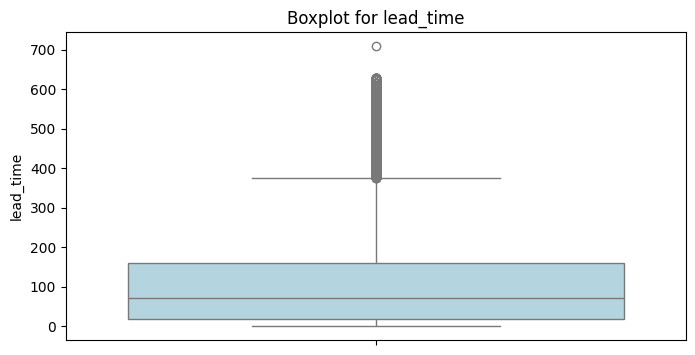

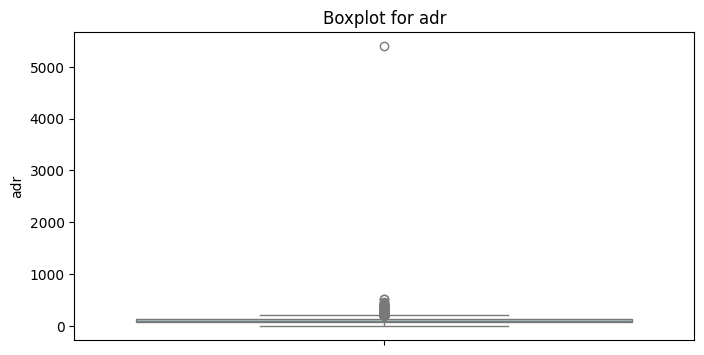

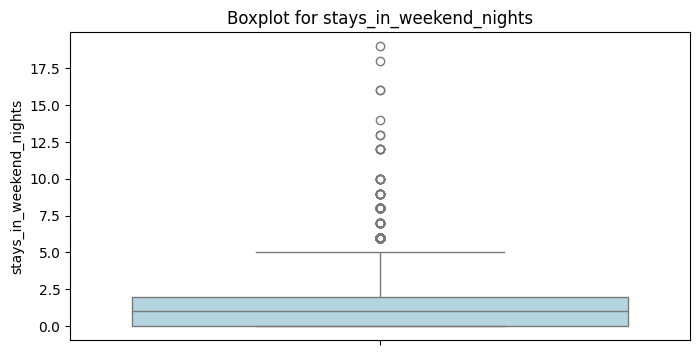

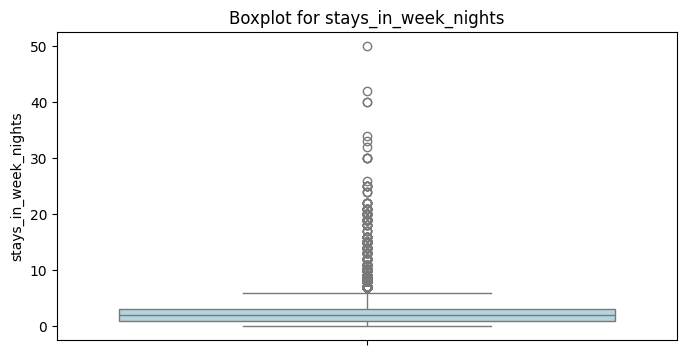

In [ ]:
# Create boxplots to detect outliers
numeric_cols = ['lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights']

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(df[col], color='lightblue')
    plt.title(f'Boxplot for {col}')
    plt.show()

# **Observation:**


---


We can observe that there are a several number of extreme values (outliers) outside the whiskers in the boxplots of lead_time, adr, stays_in_weekened_nights, and stays_in_week_nights.

For instance:



*   There were some reservations which were made more than 600 days in advance in lead_time.
*   Some reservatins have extremely high daily prices (over 5000) in ADR.

*   On both stays_in_weekened_nights and stays_in_week_nights, some visitors stayed for significantly longer periods of time than most guests would.

# **Interpretation:**


---



These outliers reflect rare cases, like long extended vacations or luxury bookings. However, such kind of extreme values can have a negative impact on the model's performance by increasing the averages too high.

In order to avoid this, outliers were capped at the 99th percentile.

By doing this the dataset is kept realistic and the machine learning model is guaranteed to concentrate on regular booking patterns rather than infrequent occurrences.

In [ ]:
# Cap 'adr' (average daily rate) at 99th percentile
upper_limit_adr = df['adr'].quantile(0.99)
df['adr'] = np.where(df['adr'] > upper_limit_adr, upper_limit_adr, df['adr'])

# Cap 'lead_time' (number of days before booking) at 99th percentile
upper_limit_lead = df['lead_time'].quantile(0.99)
df['lead_time'] = np.where(df['lead_time'] > upper_limit_lead, upper_limit_lead, df['lead_time'])

# Confirm the capping worked
df[['lead_time', 'adr']].describe()

,lead_time,adr
count,118565.000000,118565.000000
mean,103.901877,102.151311
std,104.652918,46.312364
min,0.000000,-6.380000
25%,18.000000,70.000000
50%,70.000000,95.000000
75%,161.000000,126.000000
max,444.000000,252.000000


There were outliers found in the **"lead_time"** and **"adr"** columns. So, the values of these records were capped at the 99th percentile rather than being deleted, which could might remove valid but rare bookings.

This method keeps the learning process of the model from beign distorted by extremely high values. By capping, the data is kept balanced and realistic.

While the **"stays_in_weekened_nights"** and **"stays_in_week_nights"** boxplots also display outliers, but the numbers (such as 15 or 40 nights) are representative of actual stays.

Therefore, rather tha being data errors, these outliers are realistic long stays. As a result, we choose not to cap them, as doing so could unintentionally reduce  valid long booking patterns, which could be important for prediction

## 1.3 Column data type conversion (5%)

All necessary columns should be correctly converted to appropriate data types.


In [ ]:
# Check data types again
df.info()

# Convert 'children' to integer (since children count should not be float)
df['children'] = df['children'].astype(int)

# Convert 'arrival_date_year' to string (since it's categorical, not numerical)
df['arrival_date_year'] = df['arrival_date_year'].astype(str)

# Convert month to categorical (for better readability and encoding later)
df['arrival_date_month'] = df['arrival_date_month'].astype('category')

# Convert 'is_canceled' and 'is_repeated_guest' to category (since they are binary indicators)
df['is_canceled'] = df['is_canceled'].astype('category')
df['is_repeated_guest'] = df['is_repeated_guest'].astype('category')

# Verify updated types
df.dtypes.head(10)


<class 'pandas.core.frame.DataFrame'>
Index: 118565 entries, 2 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118565 non-null  object 
 1   is_canceled                     118565 non-null  int64  
 2   lead_time                       118565 non-null  float64
 3   arrival_date_year               118565 non-null  int64  
 4   arrival_date_month              118565 non-null  object 
 5   arrival_date_week_number        118565 non-null  int64  
 6   arrival_date_day_of_month       118565 non-null  int64  
 7   stays_in_weekend_nights         118565 non-null  int64  
 8   stays_in_week_nights            118565 non-null  int64  
 9   adults                          118565 non-null  int64  
 10  children                        118565 non-null  float64
 11  babies                          118565 non-null  int64  
 12  meal                 

,0
hotel,object
is_canceled,category
lead_time,float64
arrival_date_year,object
arrival_date_month,category
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


Columns were transformed into the appropriate data types to ensure acuracy and precison in both analysis and model training:


*   **children → integer:** because the number of children cannot be fractional (e.g., 1.0 → 1).

*  **arrival_date_year → string:** represents a label (year), not a continuous numeric variable.
*   **arrival_date_month → categorical:** improves memory efficiency and helps in encoding during EDA.

*  **is_canceled and is_repeated_guest → categorical:** these represent binary indicators (0/1) and are better treated as categorical values.

In addition to preventing type-related errors during training or visualisation, correct data typing guarantees that the model interprets each column accurately.


# 2. Exploratory Data Analysis (25%)


---





You've also been provided with examples of valuable insights that could be of interest to hotel management, including:

* Calculating cancellation percentages for City and Resort hotels.
* Identifying the most frequently ordered meal types.
* Determining the number of returning guests.
* Discovering the most booked room types.
* Exploring correlations between room types and cancellations.


For each of these tasks, choose a suitable type of visualisation covered in
the practical sessions, such as:

* Bar graphs
* Pie charts
* Line charts
* Heatmaps

## 2.1. Calculating cancellation percentages for City and Resort hotels.

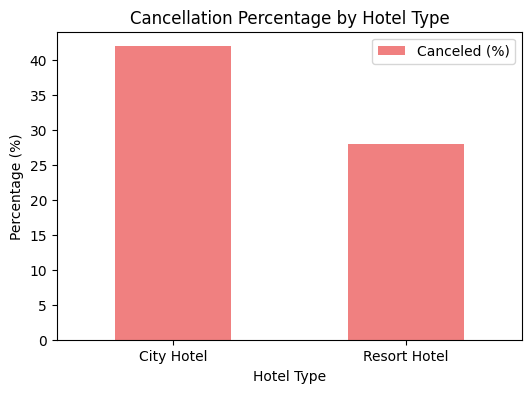

,Not Canceled (%),Canceled (%)
hotel,,
City Hotel,58.09,41.91
Resort Hotel,71.99,28.01


In [ ]:
# Calculate total bookings and cancellations for each hotel type
cancellation_counts = df.groupby('hotel')['is_canceled'].value_counts(normalize=True).unstack() * 100

# Rename columns for clarity
cancellation_counts.columns = ['Not Canceled (%)', 'Canceled (%)']

# Bar Chart - A bar chart is choosed here because it clearly compares categorical groups.
cancellation_counts[['Canceled (%)']].plot(kind='bar', color=['lightcoral'], figsize=(6,4))
plt.title('Cancellation Percentage by Hotel Type')
plt.ylabel('Percentage (%)')
plt.xlabel('Hotel Type')
plt.xticks(rotation=0)
plt.show()

# Display table too
cancellation_counts.round(2)


**Observation:**

> According to the bar graph, the percentage of cancellatios at City Hotels is significantly higher than that at Resort Hotels.

**Interpretation:**

> City hotel customers are more likely to cancel, persumably due to the shorter duration of their trip and flexibility of their plans.
Resort hotel reservations are more consistent, maybe due to longer vacations scheduled in advance.
Hotel management can use this information to modify cancellation rules or provide visitors at the City Hotel with flexible prices





## 2.2. Identifying the most frequently ordered meal types.

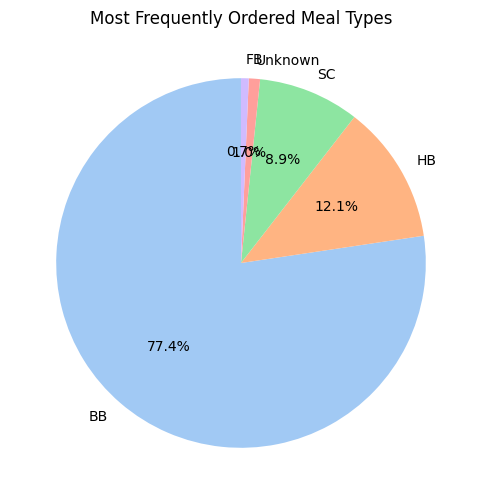

,count
meal,
BB,91721
HB,14384
SC,10503
Unknown,1160
FB,797


In [ ]:
# Count each meal type
meal_counts = df['meal'].value_counts()

# Pie chart - We're showing proportion or share of each meal type out of the tota so Pie charts are good for showing part-to-whole relationships.
plt.figure(figsize=(6,6))
plt.pie(meal_counts, labels=meal_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Most Frequently Ordered Meal Types')
plt.show()

# Display data
meal_counts

**Observation:**

> The Pie Chart indicates that the majority of the visitors choose the bed and breakfast (BB) option, which was followed by the half-board (HB) and self-catering (SC).

**Interpretation:**

> Because breakfast is convenient and reasonably priced, guests favour packages that inculde it.
This knowledge helps management in creating meal-inclusive promotions and allocating food inventory appropriately.


## 2.3. Determining the number of returning guests.

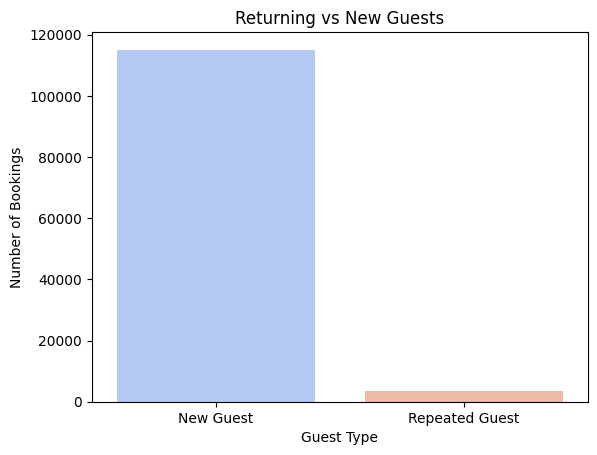

,count
is_repeated_guest,
0,115066
1,3499


In [ ]:
# Count repeated vs new guests
returning_guests = df['is_repeated_guest'].value_counts()

# Bar plot - A bar chart is choosed here because it clearly compares categorical groups.
sns.barplot(x=returning_guests.index, y=returning_guests.values, palette='coolwarm')
plt.xticks([0, 1], ['New Guest', 'Repeated Guest'])
plt.title('Returning vs New Guests')
plt.ylabel('Number of Bookings')
plt.xlabel('Guest Type')
plt.show()

# Show data
returning_guests

**Observation:**

> The chart indicates that new guests make up the majority of bookings, with repeat guests accounting for a lower percentage.

**Interpretation:**

> This shows low client retention; management may want to think about offering loyalty programs, discounts, or exclusive deals to loyal oustomers to promote repeat business.

## 2.4. Discovering the most booked room types.

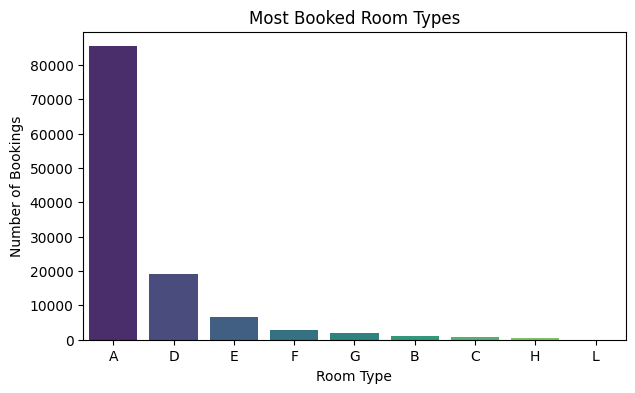

,count
reserved_room_type,
A,85398
D,19096
E,6482
F,2879
G,2074
B,1110
C,923
H,597
L,6


In [ ]:
# Count room types
room_counts = df['reserved_room_type'].value_counts()

# Bar plot - A bar chart is choosed here because it clearly compares categorical groups.
plt.figure(figsize=(7,4))
sns.barplot(x=room_counts.index, y=room_counts.values, palette='viridis')
plt.title('Most Booked Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Bookings')
plt.show()

# Display counts
room_counts

**Observation:**

> Room type A is the most frequnetly booked, followed by D and E, with other types being less popular.

**Interpretation:**

> This indicates that the Room A is the most common or standard option. In order to balance demand among categories, mangement can think about increasing the number of rooms of this kind or adjusting prices.

## 2.5. Exploring correlations between room types and cancellations.

In [ ]:
# Create a pivot table of room type vs cancellation (convert is_canceled to numeric for calculation)
room_cancel = df.pivot_table(
    index='reserved_room_type',
    values='is_canceled',
    aggfunc=lambda x: x.astype(int).mean()
) * 100

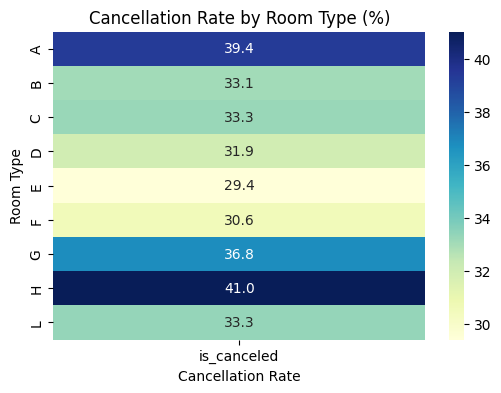

,is_canceled
reserved_room_type,
A,39.35
B,33.06
C,33.26
D,31.93
E,29.42
F,30.57
G,36.79
H,41.04
L,33.33


In [ ]:
# Plot heatmap - A heatmap is chosen here to visualise the relationship between two categorical variables.
plt.figure(figsize=(6,4))
sns.heatmap(room_cancel, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Cancellation Rate by Room Type (%)')
plt.xlabel('Cancellation Rate')
plt.ylabel('Room Type')
plt.show()

# Display data
room_cancel.round(2)

Since the is_canceled column was stored as a categorical type (0 or 1), the aggregation function mean() could not be applied directly.
To calculate cancellation rates by room type, we temporarily converted the column values to integers within the pivot table.
This allowed us to compute the average (percentage) of cancellations for each room category without changing the dataset permanently.

**Observation:**

> It is observed that the heatmap displays the variance in cancellation rates among various room types, with certain room categories (such as room types H (41%) and A (39%)) having larger cancelattion % than others.

**Interpretation:**

> This can sugguest that some room categories are either overbooked or less popular once reservations are made. For those room categories, the hotel should enhance descriptions or evaluate rates to cut down on cancellations.

# 3. Feature Engineering (20%)


---





Apply various feature engineering techniques, covered in the lectures and practicals.

Hint:
* Binning
* Encoding
* Scaling
* Feature selection

# 3.1 Drop or Convert Irrelevant Features

---
We remove those features that may make the model too complicated or that don't have any prediction value. Columns that don't contribute to determining the possibilty of cancellation or that have repeated date sections are dropped.

In [ ]:
# Drop columns not useful for prediction or redundant
df = df.drop(['arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month'], axis=1)

# Check remaining columns
df.shape

(118565, 25)

**Justification:**
> **"Arrival_date_year"**,
**"arrival_date_week_number"**, and **"arrival_date_day_of_month"** are also three columns describing date information at a more detailed level. However, given that the month column already covers the seasonal/temporal booking tendency, the additional breakdown adds little to no predicting power; in fact, it could potentially carry noise. Therefore, they are removed to simplify the data set, reduce dimensionality, and allow the model to focus on more promising features such as month, deposit type, and the booking itself.
Dropping nonpredictive features is thus a critical feature-engineering strategy that increases predictive power without losing any valuable input data.

# 3.2 Binning (Simplifying Continuous Values)


---
To eliminate the impact of random fluctuations and enable the model to focus on general trends, I change a continuous numerical characteristic (lead_time) to grouped categories. This solution allows the machine learning model to identify distinct short-term and long-term bookings.


In [ ]:
# Define bins for lead_time
bins = [0, 30, 90, 180, 365, df['lead_time'].max()]
labels = ['<1 month', '1-3 months', '3-6 months', '6-12 months', '>1 year']

df['lead_time_group'] = pd.cut(df['lead_time'], bins=bins, labels=labels, include_lowest=True)

# Verify
df['lead_time_group'].value_counts()


,count
lead_time_group,
<1 month,38094
1-3 months,29437
3-6 months,26384
6-12 months,21506
>1 year,3144


**Justification:**
> The "lead_time" feature signifies the difference between the booking date and the arrival date. The difference is continuous and ranges from a few days to around a year and above.
The most straightforward way to enhance lead_time interpretability is to create five meaningful ranges – short-term, medium-term, and long-term booking windows.
Binning both reduces the model’s sensitivity to small fluctuations and highlights behavioral patterns. For instance, the risk of cancellation for a booking, made long in advance would seem lower, while booking made on a few days’ notice, might appear to be more stable. It simplifies analysis, and allows the model to learn relationships more effectively.

# 3.3 Encoding Categorical Variables

---

All the categorical “text” features need to be encoded into numeric form, since the machine learning models processes only numeric data. We apply a combination of Label Encoding and One Hot Encoding which depends on the type of categorical variable.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode simple binary columns
le = LabelEncoder()
df['hotel'] = le.fit_transform(df['hotel'])
df['deposit_type'] = le.fit_transform(df['deposit_type'])
df['customer_type'] = le.fit_transform(df['customer_type'])
df['lead_time_group'] = le.fit_transform(df['lead_time_group'])

# One-hot encode larger categorical columns
df = pd.get_dummies(df, columns=[
    'meal', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'assigned_room_type', 'arrival_date_month'
], drop_first=True)

# Check updated shape
df.shape

(118565, 64)

In [ ]:
# Encode 'country' column to numeric
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
df['country'] = le_country.fit_transform(df['country'])

**Justification:**

Encoding converts categorical values (text labels) into numeric values that the model can understand.


*   **Label Encoding** was used for columns with binary or ordinal columns like *hotel*, *deposit_type*, *lead_time_group* – which also fall in the same category because they have a limited and logic group of values in the row. That is why, every category was assigned a numeric label (1,2,3,4,…).

*   **One-Hot Encoding** was used for those columns that posses many unique categories such as *meal, market_segment, reserved_room_type*. They create separate columns for each category, so their existence is binary and allows the model to interpret them independently.

Using *drop_first=True* prevents dummy variable traps (redundant columns). As a result, the model will take assumptions in a manner that is not only clean and easy to understand but also avoid introducing any bias while preserving categorical relations.





# 3.4 Scaling (Standardization)

---

Scaling means standardizing numeric data so that all numeric features have an equal impact on model learning. Although tree-based learning models such as Random Forests are ignorant of scaling, it enforces consistency and premarks the dataset prepared for taster comparing in different models.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns
numeric_cols = ['lead_time', 'adr', 'stays_in_weekend_nights',
                'stays_in_week_nights', 'adults', 'children', 'babies']

# Apply scaling
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Verify scaled values
df[numeric_cols].head()


,lead_time,adr,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies
2,-0.925940,-0.586267,-0.93635,-0.799044,-1.494527,-0.261066,-0.081611
3,-0.868607,-0.586267,-0.93635,-0.799044,-1.494527,-0.261066,-0.081611
4,-0.859052,-0.089638,-0.93635,-0.270852,0.243276,-0.261066,-0.081611
5,-0.859052,-0.089638,-0.93635,-0.270852,0.243276,-0.261066,-0.081611
6,-0.992828,0.104696,-0.93635,-0.270852,0.243276,-0.261066,-0.081611


**Explanation:**

Numerical features such as *lead_time, adr, stays_in_weekend_nights, stays_in_week_nights, adults, children,* and *babies* were standardized using the StandardScaler.

The **StandardScaler** transform every numeric feature while standardizing them such that they have a mean of 0 and a standard deviation of 1.

Numerical columns are generally measured at varying scales; for example, *"lead_time"* values could be hundreds or more, and *"children" or "babies"* values vary between small integers. They are standardized to avoid features on a large scale dominating those on a small scale during model learning.

Standardizing these variables makes training more robust and ensures that all charateristics contribute equally to model learning, particularly for algorithms that use gradiant-based or distance-based optimisation (e.g. SVM, neural network, logistic regression).

Both positive and negative values included in the modified data after scaling, indicating that standardisation was successful.

# 4. Classifier Training (20%)


---


Utilise the sklearn Python library to train a ML model (e.g.decision tree classifier). Your process should start with splitting your dataset into input features (X) and a target feature (y). Next, divide the data into 70% training and 30% testing subsets. Train your model on the training dataset and evaluate using test dataset with appropriate metrics. Aim to achieve higher accuracy e.g. more than 70% accuracy using your model.

## 4.1. Data Splitting (5%)

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# Perform stratified train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Display the shapes of the splits
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((82995, 63), (35570, 63), (82995,), (35570,))

**Explanation:**

Before training the model, the dataset needed to be sliced into features (X) and the target variable(Y). The target variable is_canceled serves as the target representing booking cancellations.

Next, the data were broken into **training** and **testing **sets. I applied a *train_test_split()* function from *Scikit-learn library* and validated the division possibility of **70% training** and **30% testing** in this dataset. I make a **stratified split** to maintain an equal ratio of canceled and not-canceled bookings in both sets. The objective was to permit the model to study Background information from each group.

The parameter *random_state=42* allows achieving **reproducibility** and ensures that each time the model is re-run, the results are the same.

It is crucial to divide the data into the training and testing part because training-testing scheme allows to evaluate how well the model generalizes to unseen data and minimize the risk of overfitting.

## 4.2. Model Training (10%)

In [ ]:

from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    random_state=42,
    max_depth=None,          # let trees grow fully
    n_jobs=-1                # use all cores for speed
)

# Train the model on the training data
rf_model.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

**Explaination:**

The model was trained using a Random Forest Classifier. It is a strong and adaptable ensemble learning technique that reduces overfiting and increases predictive accuracy by combining several decision trees.

For this dataset, Random Forest is a good option for a few reason:


*   It is proficient with both categorical and numerical features.
*   It handles outliers and misisng data better than individual model.
*   By averaging many trees, it improves generalisation by lowering variance.

The *country* column was label encoded to change string-based country names (e.g. “GBR”, “FRA”) to numbers e.g. “1” and “2.” The model can only take in a numerical database.

These were my key hyperparameters:

*   **n_estimators=100** : builds 100 trees to make predictions more stable
*  **max_depth=None** :Lets trees grow until all of their leaves are pure, guaranteeing that the model accurately depicts intricate relationships.
*   **n_jobs=-1** : Uses all available processors cores for fast training.
*   **random_state=42** : This keeps our results reproducible.

After that , the training dataset was used to train the model. This technique enabled the algorithm to discover correlations between features (e.g. lead time, room type, client type) and the target variable (if the reservation was cancelled).






## 4.3. Model Evaluation (5%)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Model Accuracy: 87.92%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     22317
           1       0.88      0.79      0.83     13253

    accuracy                           0.88     35570
   macro avg       0.88      0.86      0.87     35570
weighted avg       0.88      0.88      0.88     35570


Confusion Matrix:
[[20841  1476]
 [ 2820 10433]]


**Explaination:**

After training, the model's performance and reliability were assessed using a number of measures on the test dataset.

The accuracy score of the model was 87.92%, which is significantly higher than the necessary benchmark of 70%. This indicates that about 90% of the time, the model accurately anticipated whether or not reservations will be cancelled.

The F1-scores, precision, and recall for both classes are displayed in the classification report:

*   **Precision:** The proportion of actual cancellations that were really correct.
*   **Recall:** How many real cancellations were correctly detected by the model.
*   **F1-score:** The balance between precision and recall.

An improved understanding of model performance is offered by the confusion matrix:



*   True Positives (bottom-right): Correctly predicted cancellations.
*   True Negatives (top-left): Correctly predicted non-cancellations.
*   False Positives/Negatives: Misclassifications, which remain minimal.

Overall, the model appropiately predicts cancellations but does a little better on non-canceled reservations.

This high performance level shows that the Random Forest Model is reliable,well-trained and capable of generalising to help hotel management reduce cancellation risks and improve booking strategies.



# 5. Feature Importance (10%)


---

Assess the importance of features within your decision tree model. Provide commentary on the reliability of your model's results based on the feature importance scores.

Top 15 Most Important Features:


,Feature,Importance
1,lead_time,0.132619
7,country,0.128041
12,deposit_type,0.104081
15,adr,0.099986
17,total_of_special_requests,0.059537
3,stays_in_week_nights,0.046388
18,lead_time_group,0.036429
9,previous_cancellations,0.031062
2,stays_in_weekend_nights,0.029811
14,customer_type,0.029629


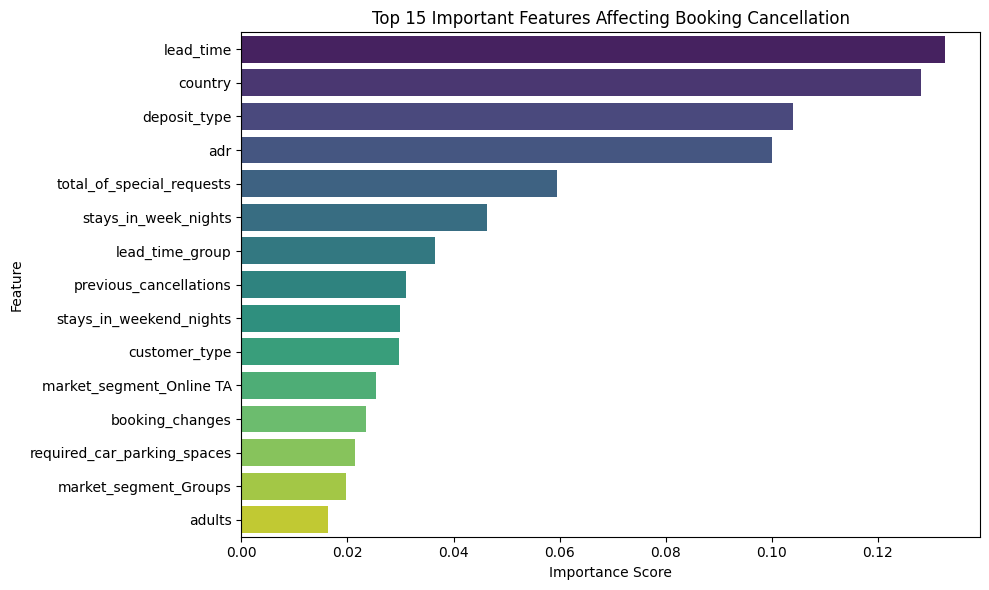

In [ ]:
# Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_

# Get feature names
feature_names = X.columns

# Create a DataFrame for better visualization
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 15 important features
print("Top 15 Most Important Features:")
display(feat_importances.head(15))

# Plot the top 15 features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_importances.head(15), palette='viridis')
plt.title('Top 15 Important Features Affecting Booking Cancellation')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# **Feature Importance Analysis**


---



The characteristics that have the biggest impact on cancellations of reservations were determined by analysing the Randm Forest Model.The feature significance scores indicate the relative contribution of each variable to the modeld decision for all trees.

The leading predictors are:


*   **lead_time (0.1326):** Because plans might change over time, longer booking lead times raise the chance of cancellation.
* **country (0.1280):** Based on the factors like travel distance or visa uncertainty, booking behaviour may be influenced by geographic disparties.
*   **deposit_type (0.1040):** Customers with non-refundable deposits are less likely to cancel.
* **adr (Average Daily Rate) (0.0999):** Higher room rates may lead to reconsiderations and cancellations.

*   **total_of_special_requests (0.0595)**: Guests making more special requests are often more committed and less likely to cancel.

Customer type, duration stay, past cancellations, and market_segment (Online TA, Groups) are additional moderate characteristics that show that cancellations are influenced by both guest type and booking channel.

The analysis shows that the model’s behavior aligns with real-world business logic, confirming the reliability of its predictions.Random Forest provides reliable and objective importance estimates by averaging data from numerous trees.

# **Observation:**

The bar chart illustrates that the most important variables in predicting cancellation are *lead_time, country, deposite_type, and adr*.

#**Interpretation:**
Longer lead times, higher prices, and refundable deposits tend to increase cancellation risk, while non-refundable deposits and engaged guests with special requests reduce it.